### Principal Component Analisys
PCA is perfomred to reduce the dimensionality of the data while retaining most of the variance.
This help in symplifying the dataset, reducing noise and making it easier to visualize and interpret.

In [11]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('geochemical_data_final.csv')
print(data.columns)

# Separate features and response variables
features = data.iloc[:, 4:17]
reservoir_T = data.iloc[:, -1]
print(f'Features of dataset: {features.columns}')
print(f'Number of compenents in features: {features.shape[1]}')
print(reservoir_T.head())

Index(['name', 'manifestation_type', 'geothermal_system', 'id', 't_out', 'pH',
       'ac_carbonate', 'chloride', 'sulfate', 'calcium', 'magnesium', 'sodium',
       'potassium', 'lithium', 'silica', 'δ18O-H2O', 'δD-H2O', 'T_reservoir'],
      dtype='object')
Features of dataset: Index(['t_out', 'pH', 'ac_carbonate', 'chloride', 'sulfate', 'calcium',
       'magnesium', 'sodium', 'potassium', 'lithium', 'silica', 'δ18O-H2O',
       'δD-H2O'],
      dtype='object')
Number of compenents in features: 13
0    166.0
1    174.0
2    159.7
3    223.0
4    218.0
Name: T_reservoir, dtype: float64


In [28]:
def data_preprocess(file_path):
    data = pd.read_csv('geochemical_data_final.csv')

    # Separate features and response variables
    features = data.iloc[:, 4:17]
    reservoir_T = data.iloc[:, -1]
    
    # Standardize the features
    scaler = StandardScaler()
    data_std = scaler.fit_transform(features)

    return data_std, reservoir_T

def pca_analysis(data_std, n_components):
    pca = PCA(n_components=n_components)
    principal_components = pca.fit_transform(data_std) 

    # Explained variance ratio and cumulative variance
    evr = pca.explained_variance_ratio_
    cev = evr.cumsum()
    return principal_components, evr, cev

def optimal_components(cev, variance_to_keep):
    return np.argmax(cev >= variance_to_keep) + 1

def main():
    data_std, reservoir_T = data_preprocess('geochemical_data_final.csv')
    principals_components, evr, cev = pca_analysis(data_std, 13)

    # Determine optimal number of components to keep
    variance_to_keep = 0.95
    num_components = optimal_components(cev, variance_to_keep)

    # Print results
    print(f'\n🔹Explained variance ratio: {evr}')
    print(f'\n🔹Number of components to keep to explain {variance_to_keep*100}% of variance: {num_components}')

    # Create a DF for principal components
    pca_df = pd.DataFrame(data=principals_components[:, :num_components], columns=[f'PC{i+1}' for i in range(num_components)])
    print('\n🔹', pca_df.head())
    print(f'\n🔹Shape of principal components data frame: ', pca_df.shape)

    return variance_to_keep, pca_df, evr, cev

if __name__ == '__main__':
    main()   


🔹Explained variance ratio: [0.29782703 0.18000047 0.13624914 0.09047057 0.07387641 0.05909946
 0.05192993 0.04007768 0.02394257 0.02055235 0.01621094 0.00714591
 0.00261754]

🔹Number of components to keep to explain 95.0% of variance: 9

🔹         PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -0.914011 -0.918631  0.698195 -0.214407 -0.175358  0.341647 -0.292527   
1  0.201181 -1.071203  0.646086 -0.295684 -0.007803  0.173603 -0.642356   
2 -0.390817 -2.125723 -1.312444 -1.462087 -0.124011  0.222679 -1.570436   
3 -0.959464  0.831935 -0.100412  0.358279  0.222944 -0.334315  0.297041   
4 -1.221808  0.690270 -0.029346  0.886591  1.082517 -0.493552  0.008436   

        PC8       PC9  
0 -0.125042  0.186678  
1 -0.265647  0.301905  
2  0.319717 -0.335376  
3  0.396689 -0.135441  
4  0.216234 -0.077250  

🔹Shape of principal components data frame:  (176, 9)


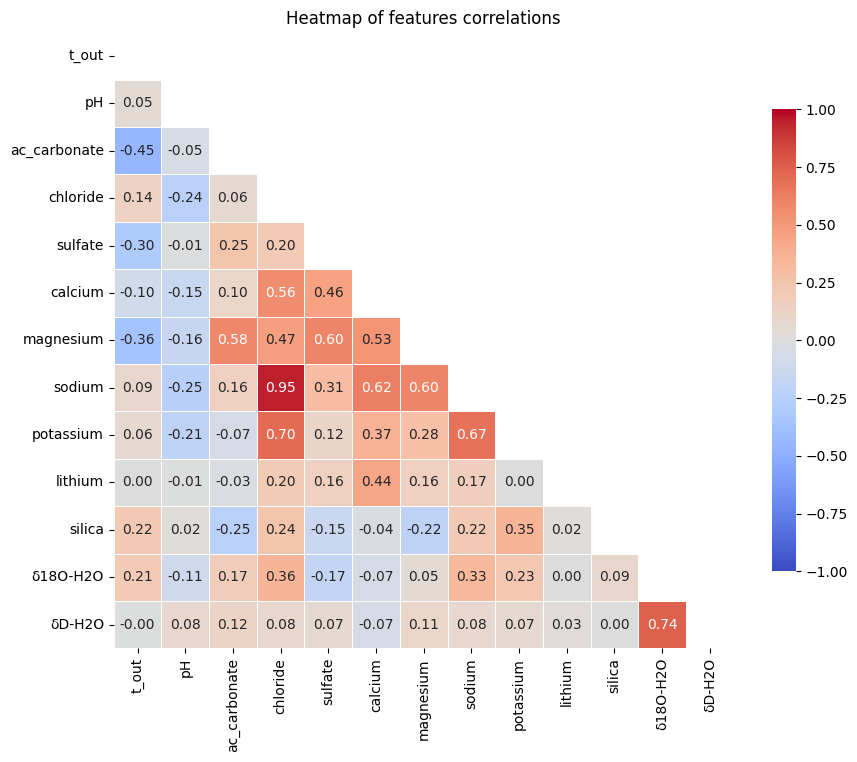

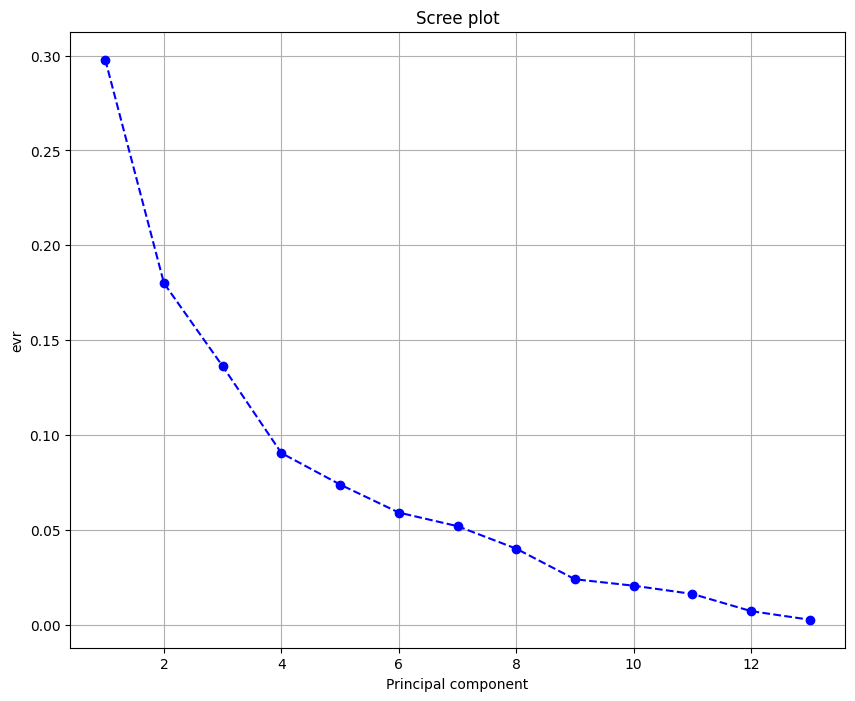

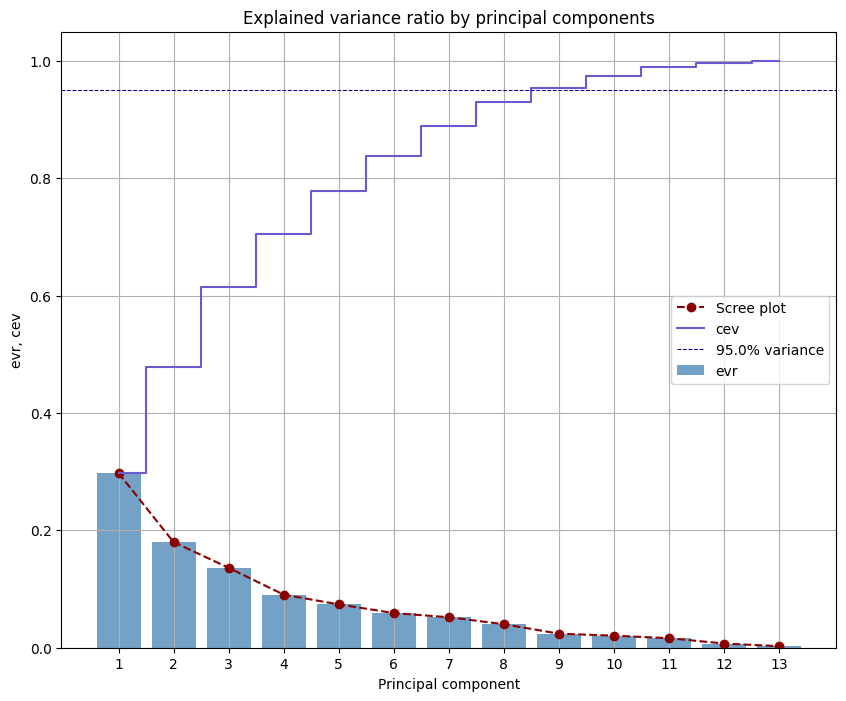

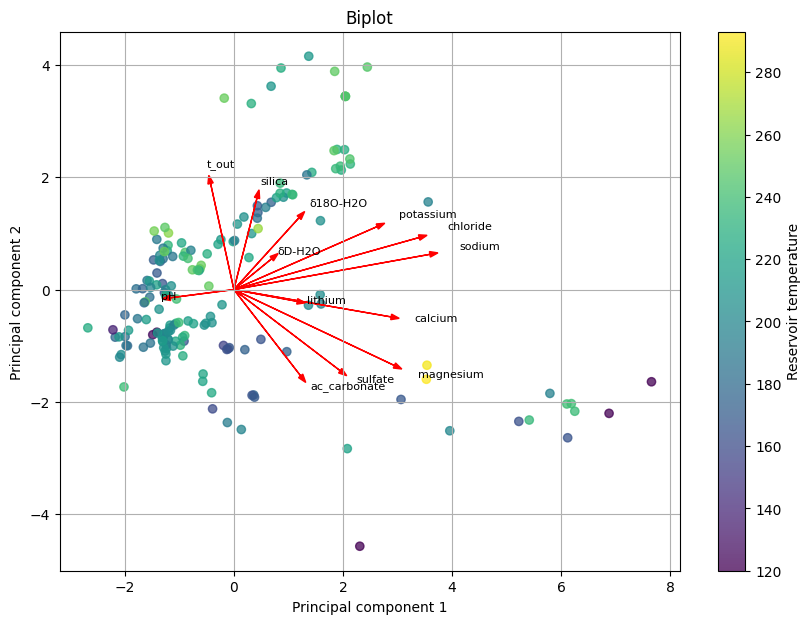

In [40]:
### PCA resultys visualization
import matplotlib.pyplot as plt
import seaborn as sns

def heatmap(features):
    correlation_matrix = features.corr()
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, mask=mask, vmin=-1, vmax=1, cbar_kws={"shrink": 0.75})
    plt.title('Heatmap of features correlations')
    plt.show()
    plt.close()

def scree_plot(evr):
    plt.figure(figsize=(10, 8))
    plt.plot(range(1, len(evr)+1), evr, marker='o', linestyle='--', color='b')
    plt.title('Scree plot')
    plt.xlabel('Principal component')
    plt.ylabel('evr')
    plt.grid(True)
    plt.show()
    plt.close()

def evr_cev(evr, cev, variance_to_keep):
    plt.figure(figsize=(10, 8))
    plt.bar(range(1, len(evr)+1), evr, alpha=0.75, align='center', label='evr', color='steelblue')
    plt.plot(range(1, len(cev)+1), evr, marker='o', linestyle='--', label='Scree plot', color='darkred')
    plt.step(range(1, len(cev)+1), cev, where='mid', label='cev', color='slateblue')
    plt.axhline(y=variance_to_keep, color='navy', lw=.75, linestyle='dashed', label=f'{variance_to_keep*100}% variance')
    plt.xlabel('Principal component')
    plt.xticks(range(1,14))
    plt.ylabel('evr, cev')
    plt.legend(loc='center right')
    plt.title('Explained variance ratio by principal components')
    plt.grid(True)
    plt.show()

def biplot(principal_components, pca, features, feature_names, reservoir_T):
    # Create a biplot
    plt.figure(figsize=(10, 7))
    plt.scatter(principal_components[:, 0], principal_components[:, 1], c=reservoir_T, cmap= 'viridis', alpha=0.75)
    plt.colorbar(label='Reservoir temperature')

    for i, feature in enumerate(feature_names):
        plt.arrow(0, 0, pca.components_[0, i]*max(principal_components[:, 0]), 
                  pca.components_[1, i]*max(principal_components[:, 1]),
                  color='r', head_width=0.1)
        plt.text(pca.components_[0, i]*max(principal_components[:, 0]) * 1.15, 
                 pca.components_[1, i]*max(principal_components[:, 1]) * 1.15, 
                 feature, color='k', fontsize=8, ha='left')
    plt.xlabel('Principal component 1')
    plt.ylabel('Principal component 2')
    plt.title('Biplot')
    plt.grid(True)
    plt.show()


def main():
    data_std, reservoir_T = data_preprocess('geochemical_data_final.csv')
    principals_components, evr, cev = pca_analysis(data_std, 13)
    variance_to_keep = 0.95

    data = pd.read_csv('geochemical_data_final.csv')
    features = data.iloc[:, 4:17]
    feature_names = features.columns
    reservoir_T = data.iloc[:, -1]

    pca = PCA(n_components=13)
    pca.fit(data_std)

    pca_df = pd.DataFrame(data=principals_components, columns=[f'PC{i+1}' for i in range(13)])

    heatmap(features)
    scree_plot(evr)
    evr_cev(evr, cev, variance_to_keep)
    biplot(principals_components, pca, pd.DataFrame(data_std, columns=feature_names), feature_names, reservoir_T)

if __name__ == '__main__':
    main()  